# ============================================================
# PERSON 1 — Data Cleaning & EDA
# NLP Customer Complaint Router — SAP ABAP Capstone Project
# ============================================================
# Dataset: Use this Kaggle dataset
# https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset
# OR generate synthetic data using the function below
# ============================================================


In [11]:
%matplotlib inline

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')

In [13]:
# ── STEP 1: Load or Generate Dataset ──────────────────────────────────────────

def generate_synthetic_data(n=1000):
    """Generate synthetic SAP SD-style complaint tickets"""
    np.random.seed(42)

    categories = {
        'Billing Issue':       ['invoice wrong amount', 'charged twice', 'billing error',
                                 'incorrect bill', 'overcharged', 'payment not reflected',
                                 'wrong tax amount', 'duplicate charge'],
        'Delivery Problem':    ['order not delivered', 'late shipment', 'package missing',
                                 'wrong item delivered', 'damaged goods', 'delivery delayed',
                                 'courier issue', 'tracking not updated'],
        'Product Defect':      ['item broken', 'product not working', 'defective unit',
                                 'quality issue', 'manufacturing defect', 'item damaged',
                                 'poor quality', 'product stopped working'],
        'Refund Request':      ['want refund', 'money back', 'return and refund',
                                 'cancel and refund', 'refund not received', 'refund pending',
                                 'request for refund', 'refund status'],
        'Account Issue':       ['cannot login', 'account locked', 'password reset',
                                 'account suspended', 'profile not updating', 'login problem',
                                 'account access issue', 'forgot password'],
    }

    routing = {
        'Billing Issue':    'Finance Team',
        'Delivery Problem': 'Logistics Team',
        'Product Defect':   'Quality Team',
        'Refund Request':   'Finance Team',
        'Account Issue':    'IT Support Team',
    }

    priority_map = {
        'Billing Issue':    'HIGH',
        'Delivery Problem': 'MEDIUM',
        'Product Defect':   'HIGH',
        'Refund Request':   'MEDIUM',
        'Account Issue':    'LOW',
    }

    rows = []
    for _ in range(n):
        cat = np.random.choice(list(categories.keys()))
        base = np.random.choice(categories[cat])
        # Add some noise to make it realistic
        noise_words = ['please help', 'urgent', 'asap', 'my order', 'customer id',
                       'transaction', 'regarding', 'I have an issue with', 'complaint about']
        text = f"{np.random.choice(noise_words)} {base}"
        rows.append({
            'ticket_id':    f'TKT{1000 + _}',
            'complaint':     text,
            'category':      cat,
            'route_to':      routing[cat],
            'priority':      priority_map[cat],
            'customer_id':   f'CUST{np.random.randint(100, 999)}',
        })

    return pd.DataFrame(rows)


In [14]:
# Load dataset
print("📦 Loading dataset...")
df = generate_synthetic_data(1000)
print(f"✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.head())

📦 Loading dataset...
✅ Dataset loaded: 1000 rows, 6 columns
  ticket_id                                 complaint        category  \
0   TKT1000  I have an issue with refund not received  Refund Request   
1   TKT1001                 asap account access issue   Account Issue   
2   TKT1002       I have an issue with defective unit  Product Defect   
3   TKT1003        I have an issue with refund status  Refund Request   
4   TKT1004       I have an issue with account locked   Account Issue   

          route_to priority customer_id  
0     Finance Team   MEDIUM     CUST800  
1  IT Support Team      LOW     CUST314  
2     Quality Team     HIGH     CUST472  
3     Finance Team   MEDIUM     CUST230  
4  IT Support Team      LOW     CUST591  


In [15]:
# ── STEP 2: Basic Info ─────────────────────────────────────────────────────────

print("\n📊 Dataset Info:")
print(df.info())
print("\n🔍 Null values:")
print(df.isnull().sum())
print("\n📈 Category Distribution:")
print(df['category'].value_counts())



📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ticket_id    1000 non-null   object
 1   complaint    1000 non-null   object
 2   category     1000 non-null   object
 3   route_to     1000 non-null   object
 4   priority     1000 non-null   object
 5   customer_id  1000 non-null   object
dtypes: object(6)
memory usage: 47.0+ KB
None

🔍 Null values:
ticket_id      0
complaint      0
category       0
route_to       0
priority       0
customer_id    0
dtype: int64

📈 Category Distribution:
category
Account Issue       212
Delivery Problem    206
Refund Request      198
Product Defect      192
Billing Issue       192
Name: count, dtype: int64


In [16]:
# ── STEP 3: Text Cleaning ──────────────────────────────────────────────────────

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

df['cleaned_complaint'] = df['complaint'].apply(clean_text)
print("\n✅ Text cleaned. Sample:")
print(df[['complaint', 'cleaned_complaint']].head(3))


✅ Text cleaned. Sample:
                                  complaint  \
0  I have an issue with refund not received   
1                 asap account access issue   
2       I have an issue with defective unit   

                          cleaned_complaint  
0  i have an issue with refund not received  
1                 asap account access issue  
2       i have an issue with defective unit  


In [22]:
# ── STEP 4: EDA Visualizations ─────────────────────────────────────────────────

plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(20, 16))
fig.suptitle('NLP Complaint Router — EDA Dashboard', fontsize=20, fontweight='bold', y=0.98)

colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

In [23]:
# Plot 1: Category Distribution (Bar)
ax1 = fig.add_subplot(3, 3, 1)
cat_counts = df['category'].value_counts()
bars = ax1.bar(cat_counts.index, cat_counts.values, color=colors)
ax1.set_title('Complaint Category Distribution', fontweight='bold')
ax1.set_xlabel('Category')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, cat_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontsize=9)

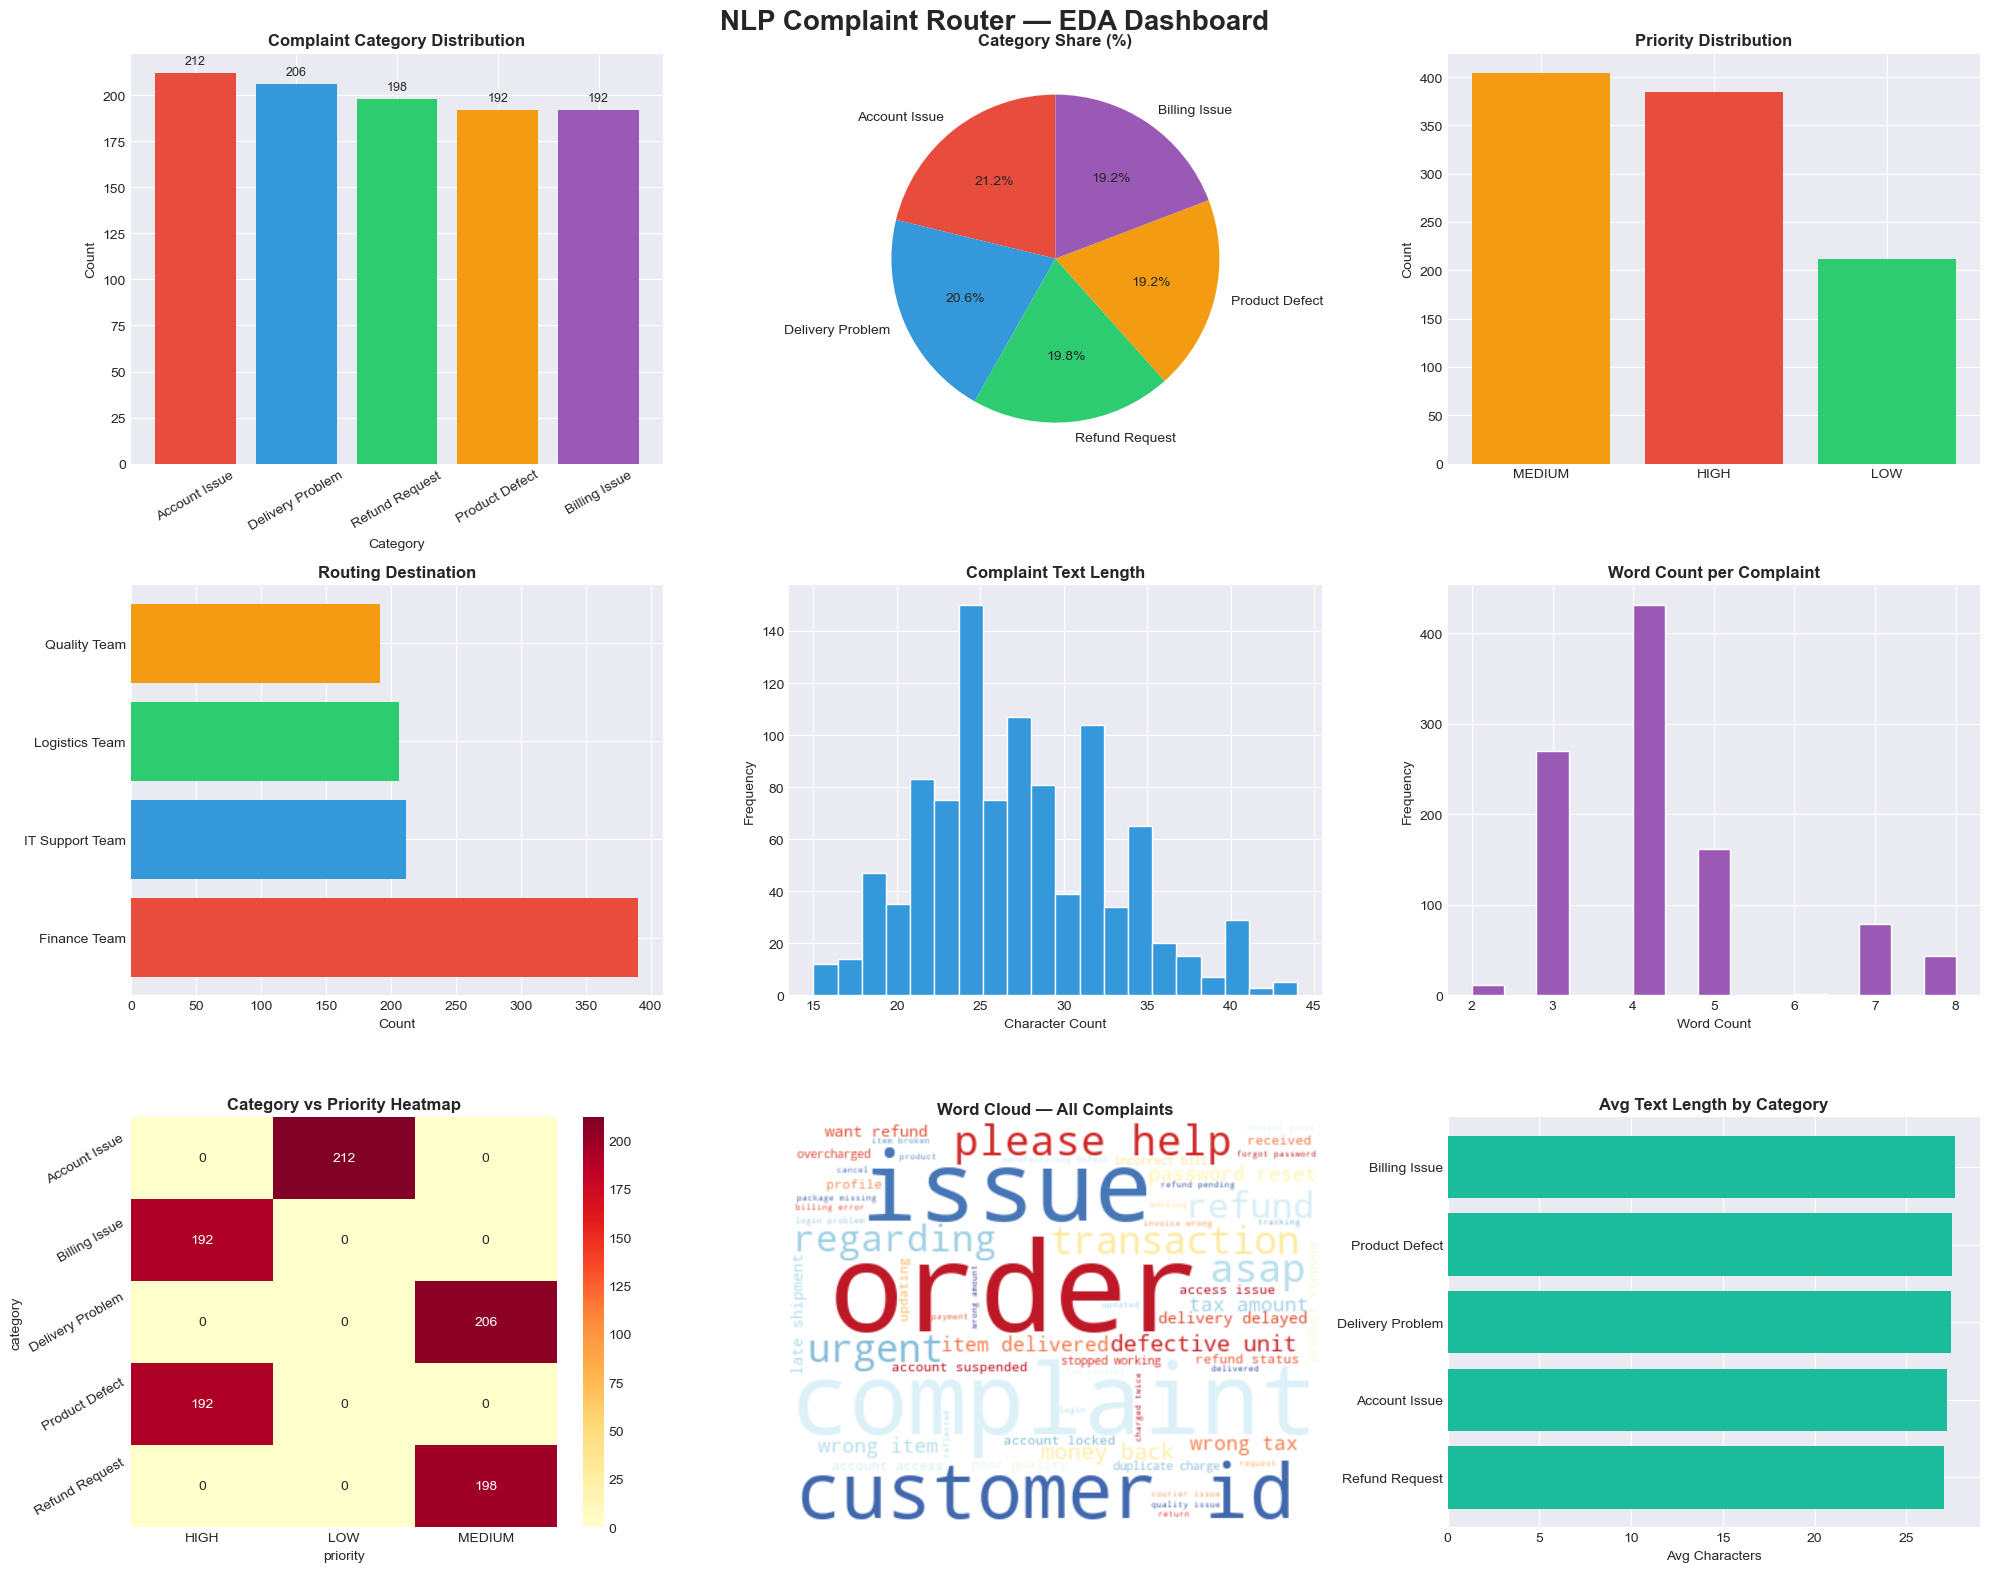


✅ EDA dashboard saved as eda_dashboard.png


In [24]:
# Plot 2: Pie Chart
ax2 = fig.add_subplot(3, 3, 2)
ax2.pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
ax2.set_title('Category Share (%)', fontweight='bold')

# Plot 3: Priority Distribution
ax3 = fig.add_subplot(3, 3, 3)
pri_counts = df['priority'].value_counts()
pri_colors = {'HIGH': '#E74C3C', 'MEDIUM': '#F39C12', 'LOW': '#2ECC71'}
bar_colors = [pri_colors[p] for p in pri_counts.index]
ax3.bar(pri_counts.index, pri_counts.values, color=bar_colors)
ax3.set_title('Priority Distribution', fontweight='bold')
ax3.set_ylabel('Count')

# Plot 4: Routing Destination
ax4 = fig.add_subplot(3, 3, 4)
route_counts = df['route_to'].value_counts()
ax4.barh(route_counts.index, route_counts.values, color=colors)
ax4.set_title('Routing Destination', fontweight='bold')
ax4.set_xlabel('Count')

# Plot 5: Complaint Text Length Distribution
ax5 = fig.add_subplot(3, 3, 5)
df['text_length'] = df['complaint'].apply(len)
ax5.hist(df['text_length'], bins=20, color='#3498DB', edgecolor='white')
ax5.set_title('Complaint Text Length', fontweight='bold')
ax5.set_xlabel('Character Count')
ax5.set_ylabel('Frequency')

# Plot 6: Word Count Distribution
ax6 = fig.add_subplot(3, 3, 6)
df['word_count'] = df['complaint'].apply(lambda x: len(x.split()))
ax6.hist(df['word_count'], bins=15, color='#9B59B6', edgecolor='white')
ax6.set_title('Word Count per Complaint', fontweight='bold')
ax6.set_xlabel('Word Count')
ax6.set_ylabel('Frequency')

# Plot 7: Heatmap — Category vs Priority
ax7 = fig.add_subplot(3, 3, 7)
cross_tab = pd.crosstab(df['category'], df['priority'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', ax=ax7)
ax7.set_title('Category vs Priority Heatmap', fontweight='bold')
ax7.tick_params(axis='x', rotation=0)
ax7.tick_params(axis='y', rotation=30)

# Plot 8: Word Cloud (all complaints)
ax8 = fig.add_subplot(3, 3, 8)
all_text = ' '.join(df['cleaned_complaint'].tolist())
wc = WordCloud(width=400, height=300, background_color='white',
               colormap='RdYlBu', max_words=80).generate(all_text)
ax8.imshow(wc, interpolation='bilinear')
ax8.axis('off')
ax8.set_title('Word Cloud — All Complaints', fontweight='bold')

# Plot 9: Avg text length per category
ax9 = fig.add_subplot(3, 3, 9)
avg_len = df.groupby('category')['text_length'].mean().sort_values()
ax9.barh(avg_len.index, avg_len.values, color='#1ABC9C')
ax9.set_title('Avg Text Length by Category', fontweight='bold')
ax9.set_xlabel('Avg Characters')

plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ EDA dashboard saved as eda_dashboard.png")


In [25]:
# ── STEP 5: Export Clean Data ──────────────────────────────────────────────────

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['category'])
train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)


In [21]:
print(f"\n✅ Data exported:")
print(f"   train.csv → {len(train_df)} rows")
print(f"   test.csv  → {len(test_df)} rows")
print("\n🎯 Person 1 task complete! Share train.csv and test.csv with Person 2 and 3.")


✅ Data exported:
   train.csv → 800 rows
   test.csv  → 200 rows

🎯 Person 1 task complete! Share train.csv and test.csv with Person 2 and 3.
